# **Convolutions, Blurring and Sharpening Images**

## **Objectives:**
1. Convolution Operations
2. Blurring
3. Denoising
4. Sharpening

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
# Our Setup, Import Libaries, Create our Imshow Function 

import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Blurring Using COnvolutions**

### What a convolution actually does

Every "blur"/"sharpen" operation below is the *same* mechanical process: slide a small grid of numbers (the **kernel**) across the image; at each position, multiply each kernel value by the pixel underneath it, add up all those products, and that sum becomes the new value of the *center* pixel. Repeat for every pixel.

That's it — the entire difference between a blur, a sharpen, and an edge detector is which numbers you put in the kernel:

- **Box blur** (`kernel_3x3` below, all `1/9`) — the new pixel is the plain average of its 3×3 neighborhood. Averaging smooths out noise but also smooths out real edges.
- **Gaussian blur** — same idea, but the weights fall off smoothly from the center (near neighbors count more than far ones) instead of being uniform, which blurs more naturally and with less "ringing".
- **Sharpen** (`kernel_sharpening`, later in this notebook) — center weight `9`, all 8 neighbors `-1`. Notice `9 - 8×1 = 1`: the kernel sums to exactly 1 (like the blur kernels do), which is what keeps overall brightness unchanged. You can read it as *original + (original − blurred)* — take the image, and add back an exaggerated version of exactly what blurring would have removed. That's "unsharp masking", and it's why sharpening amplifies noise: noise *is* the kind of fine detail a blur removes.

Concretely, for one 3×3 window:

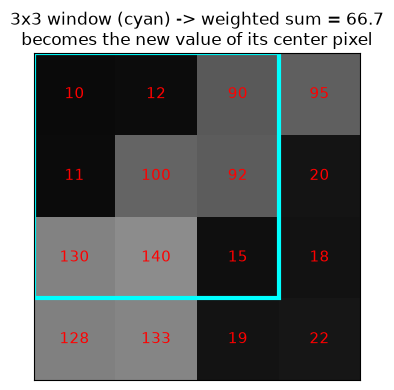

In [2]:
import numpy as np
import matplotlib.pyplot as plt

patch = np.array([
    [ 10,  12,  90, 95],
    [ 11, 100,  92, 20],
    [ 130, 140, 15, 18],
    [ 128, 133, 19, 22],
])
kernel = np.ones((3, 3)) / 9  # box blur
window = patch[0:3, 0:3]
output_value = float((window * kernel).sum())

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(patch, cmap='gray', vmin=0, vmax=255)
for (r, c), v in np.ndenumerate(patch):
    ax.text(c, r, str(v), ha='center', va='center', color='red', fontsize=11)
ax.add_patch(plt.Rectangle((-0.5, -0.5), 3, 3, fill=False, edgecolor='cyan', linewidth=3))
ax.set_title(f'3x3 window (cyan) -> weighted sum = {output_value:.1f}\n'
             f'becomes the new value of its center pixel')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

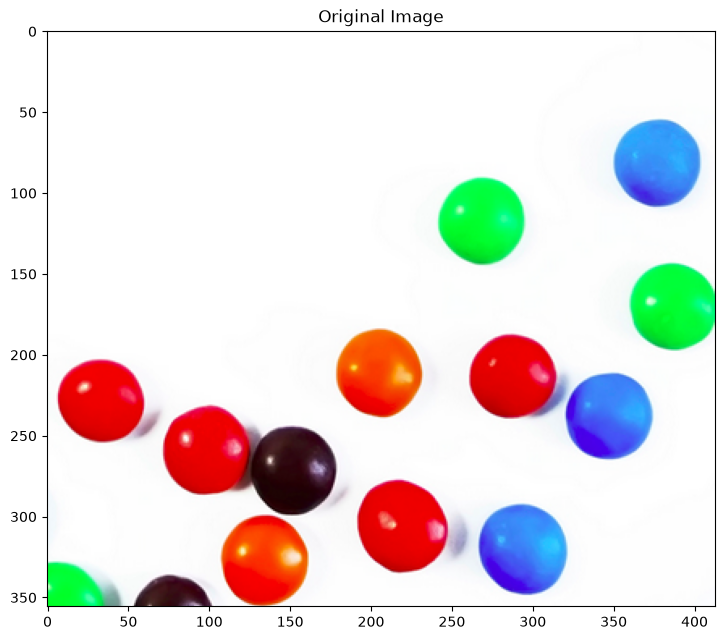

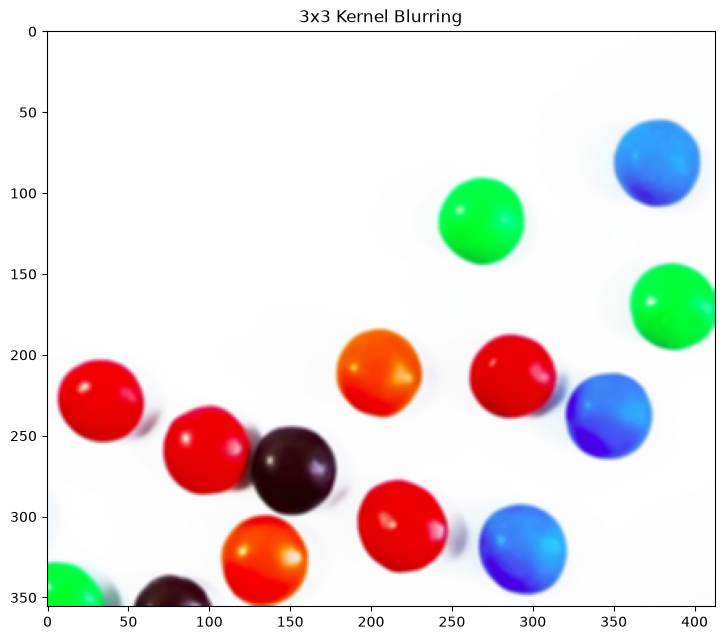

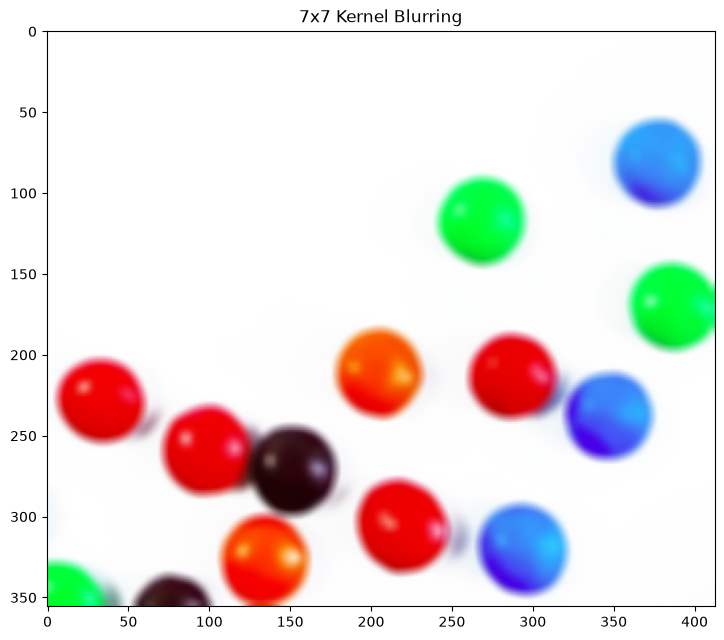

In [3]:
import cv2
import numpy as np

image = cv2.imread('assets/images/smarties.png')
imshow('Original Image', image)

# Creating our 3 x 3 kernel
kernel_3x3 = np.ones((3, 3), np.float32) / 9

# We use the cv2.fitler2D to conovlve the kernal with an image 
blurred = cv2.filter2D(image, -1, kernel_3x3)
imshow('3x3 Kernel Blurring', blurred)

# Creating our 7 x 7 kernel
kernel_7x7 = np.ones((7, 7), np.float32) / 49

blurred2 = cv2.filter2D(image, -1, kernel_7x7)
imshow('7x7 Kernel Blurring', blurred2)

### **Other lurring methods in OpenCV**
- Regular Blurring
- Gaussian Blurring
- Median Blurring

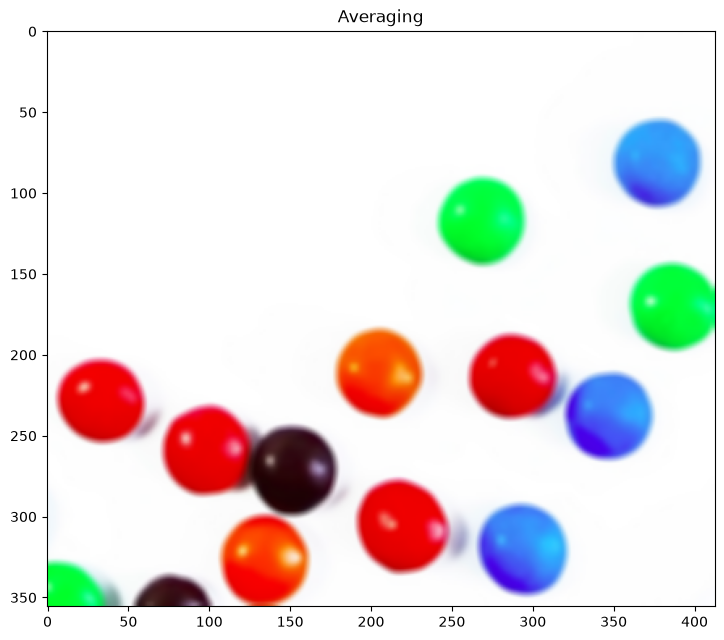

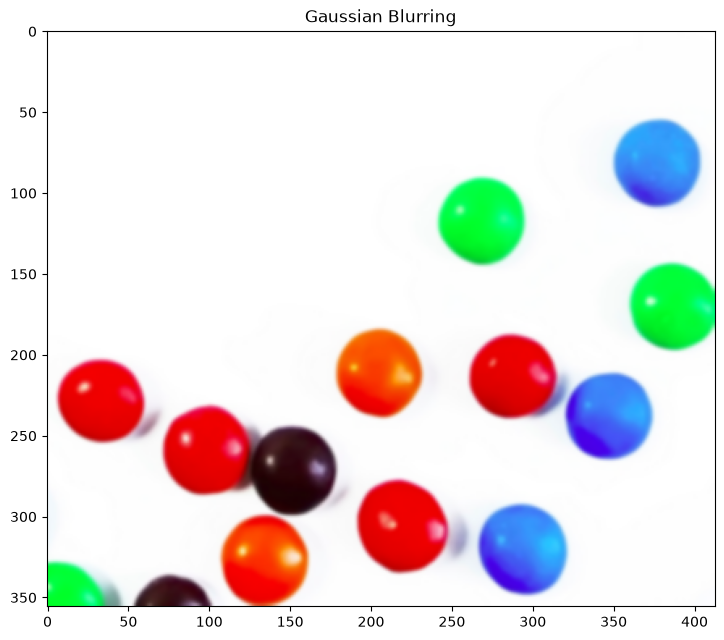

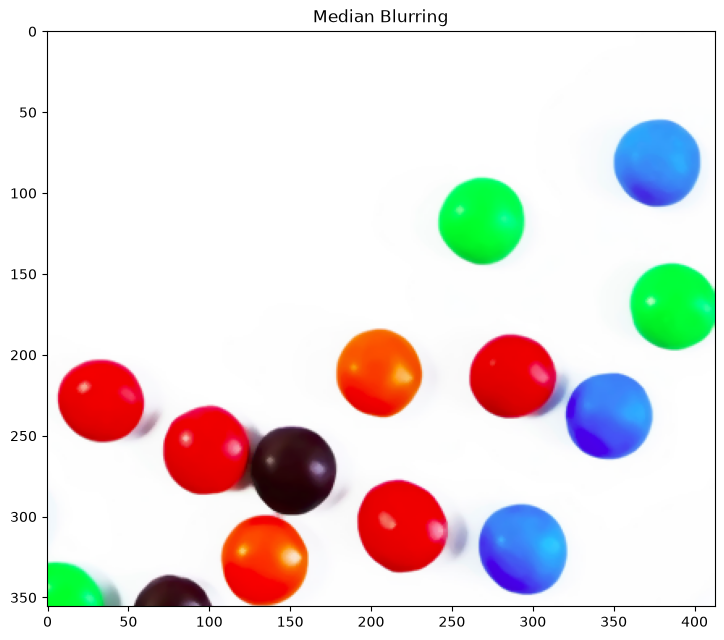

In [4]:
import cv2
import numpy as np

image = cv2.imread('assets/images/smarties.png')

# Averaging done by convolving the image with a normalized box filter. 
# This takes the pixels under the box and replaces the central element
# Box size needs to odd and positive 
blur = cv2.blur(image, (5,5))
imshow('Averaging', blur)

# Instead of box filter, gaussian kernel
Gaussian = cv2.GaussianBlur(image, (5,5), 0)
imshow('Gaussian Blurring', Gaussian)

# Takes median of all the pixels under kernel area and central 
# element is replaced with this median value
median = cv2.medianBlur(image, 5)
imshow('Median Blurring', median)

### **Bilateral Filter**
#### ```dst = cv.bilateralFilter(src, d, sigmaColor, sigmaSpace[, dst[, borderType]])```
- **src**	Source 8-bit or floating-point, 1-channel or 3-channel image.
- **dst**	Destination image of the same size and type as src .
- **d**	Diameter of each pixel neighborhood that is used during filtering. If it is non-positive, it is computed from sigmaSpace.
- **sigmaColor**	Filter sigma in the color space. A larger value of the parameter means that farther colors within the pixel neighborhood (see sigmaSpace) will be mixed together, resulting in larger areas of semi-equal color.
- **sigmaSpace**	Filter sigma in the coordinate space. A larger value of the parameter means that farther pixels will influence each other as long as their colors are close enough (see sigmaColor ). When d>0, it specifies the neighborhood size regardless of sigmaSpace. Otherwise, d is proportional to sigmaSpace.
- **borderType**	border mode used to extrapolate pixels outside of the image

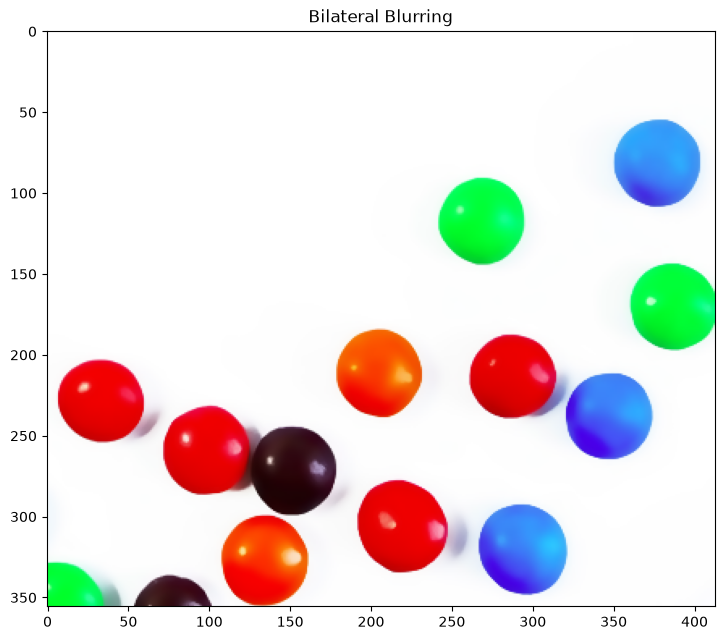

In [5]:
# Bilateral is very effective in noise removal while keeping edges sharp
bilateral = cv2.bilateralFilter(image, 9, 75, 75)
imshow('Bilateral Blurring', bilateral)

## **Image De-noising - Non-Local Means Denoising**

**There are 4 variations of Non-Local Means Denoising:**

- cv2.fastNlMeansDenoising() - works with a single grayscale images
- cv2.fastNlMeansDenoisingColored() - works with a color image.
- cv2.fastNlMeansDenoisingMulti() - works with image sequence captured in short period of time (grayscale images)
- cv2.fastNlMeansDenoisingColoredMulti() - same as above, but for color images.

```fastNlMeansDenoisingColored(source_array, OutputArray dst, float h=3, float hColor=3, int templateWindowSize=7, int searchWindowSize=21 )```

#### Parameters for fastNlMeansDenoisingColored:	

- **src** – Input 8-bit 3-channel image.
- **dst** – Output image with the same size and type as src .
templateWindowSize – Size in pixels of the template patch that is used to compute weights. Should be odd. Recommended value 7 pixels
- **searchWindowSize** – Size in pixels of the window that is used to compute weighted average for given pixel. Should be odd. Affect performance linearly: greater searchWindowsSize - greater denoising time. Recommended value 21 pixels
- **h** – Parameter regulating filter strength for luminance component. Bigger h value perfectly removes noise but also removes image details, smaller h value preserves details but also preserves some noise
- **hColor** – The same as h but for color components. For most images value equals 10 will be enought to remove colored noise and do not distort colors

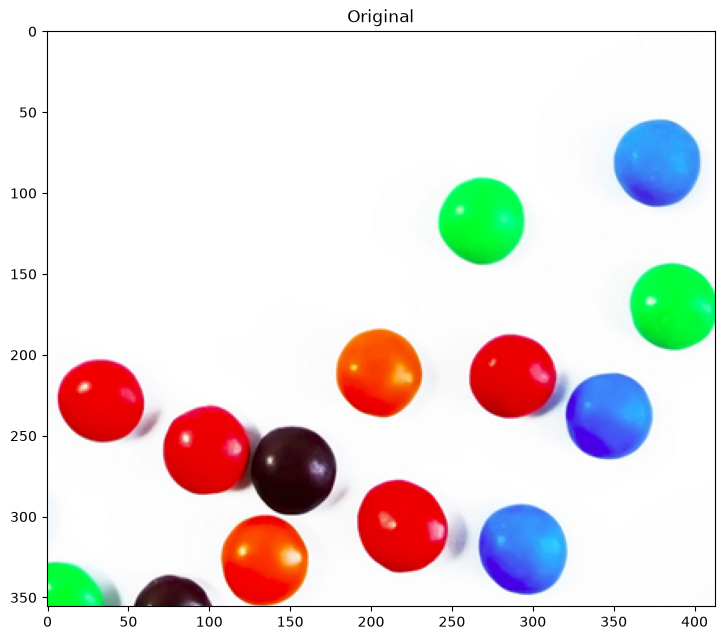

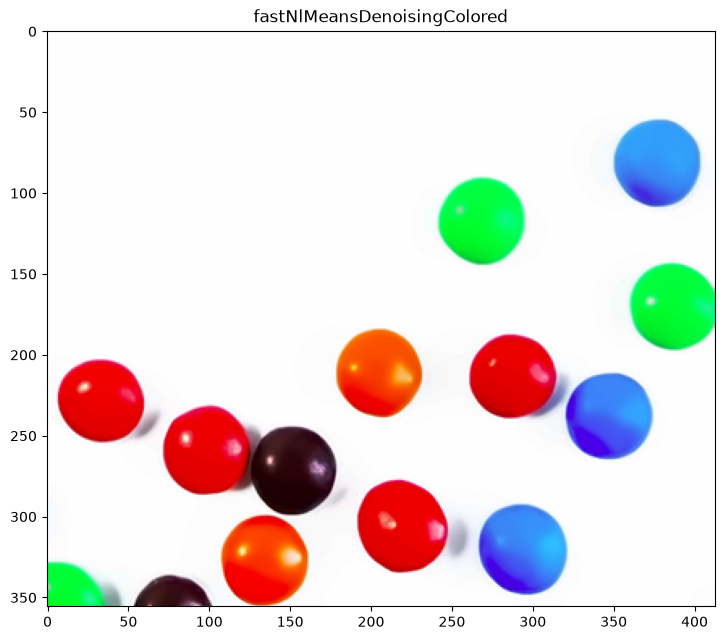

In [6]:
image = cv2.imread('assets/images/smarties.png')
imshow('Original', image)

dst = cv2.fastNlMeansDenoisingColored(image, None, 6, 6, 7, 21)
imshow('fastNlMeansDenoisingColored', dst)

### **Sharpening Images**

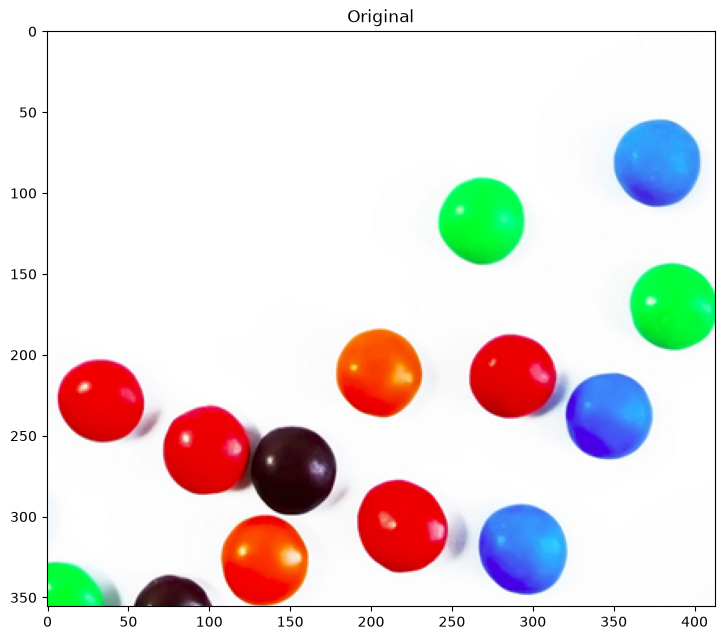

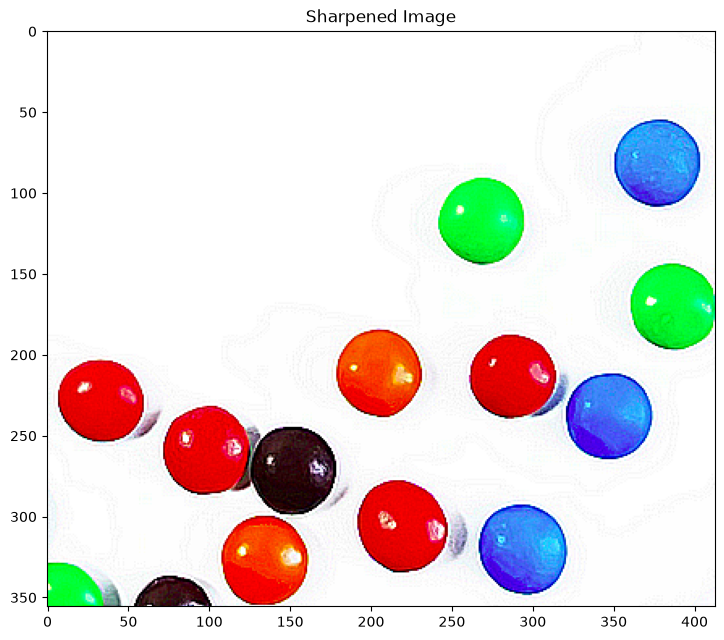

In [7]:
# Loading our image
image = cv2.imread('assets/images/smarties.png')
imshow('Original', image)

# Create our shapening kernel, remember it must sum to one 
kernel_sharpening = np.array([[-1,-1,-1], 
                              [-1, 9,-1],
                              [-1,-1,-1]])

# applying the sharpening kernel to the image
sharpened = cv2.filter2D(image, -1, kernel_sharpening)
imshow('Sharpened Image', sharpened)

### If you're curious to dig deeper

- Push the sharpening kernel further — try `[[0,-1,0],[-1,5,-1],[0,-1,0]]` (a lighter touch) vs the notebook's `[[-1]*3,[-1,9,-1],[-1]*3]` and compare edge halos.
- Denoise then sharpen, in that order, on `images/smarties.png` — a classic pipeline for cleaning up a noisy photo before further processing.